# WiniCari — 03 Delay

**Module 1: predict how late a bus will be — before it happens.**

There are **no official per-stop timetables** in the data (`ligne.horaires` only stores
origin departure times). So we measure delay against a **data-driven baseline**: the typical
time each line takes to reach each stop, learned from all the trips reconstructed in
`02_preprocessing`.

> **delay = actual elapsed-to-stop − expected elapsed-to-stop (baseline)**

Logic lives in **`src/data/delay.py`**; this notebook demonstrates it, trains the rolling
predictor, and serves ETAs.

In [ ]:
from pathlib import Path
import sys
sys.path.append(str(Path.cwd().parent))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from sklearn.metrics import mean_absolute_error

from src.data import delay as dl

CFG = dl.DelayConfig()
FOUNDATION = Path(dl.__file__).resolve().parents[2] / "data" / "processed" / "foundation_arrivals_full.parquet"

df = dl.load_foundation(FOUNDATION)
m = dl.add_daytype(dl.with_elapsed(df, CFG))# matched arrivals + elapsed + calendar features
baseline = dl.build_baseline(m, CFG)# data-driven 'schedule'
d = dl.add_daytype(dl.with_delay(m, baseline, CFG))   # + delay_min

print(f"arrivals={len(m):,} | baseline cells (>= {CFG.min_obs} trips)={len(baseline)} | "
      f"rows with delay={len(d):,}")
print(f"day range: {d['day'].min()} .. {d['day'].max()} | lines={d['line'].nunique()}")
d[["day", "line", "dir", "seq", "stop", "elapsed_min", "expected_min", "delay_min"]].head()

arrivals=128,882 | baseline cells (>= 20 trips)=549 | rows with delay=126,914
day range: 20250101 .. 20260621 | lines=16


,day,line,dir,seq,stop,elapsed_min,expected_min,delay_min
0,20250101,217,ALLER,0,KASSERINE,0.500017,2.923050,-2.423033
1,20250101,217,ALLER,1,BOUZGUEM,13.249483,18.410633,-5.161150
2,20250101,217,ALLER,3,CHRAYA,23.150600,29.954750,-6.804150
3,20250101,217,ALLER,4,SBEITLA,38.532983,46.949717,-8.416733
4,20250101,217,ALLER,5,M'GHILLA,57.032967,64.238875,-7.205908


## 1. The data-driven baseline (our "schedule")

For every `(societe, line, dir, stop)` the baseline is the **median** elapsed time from the
trip start, with a p10–p90 band showing normal spread. A run is "delayed" when it sits above
this curve.

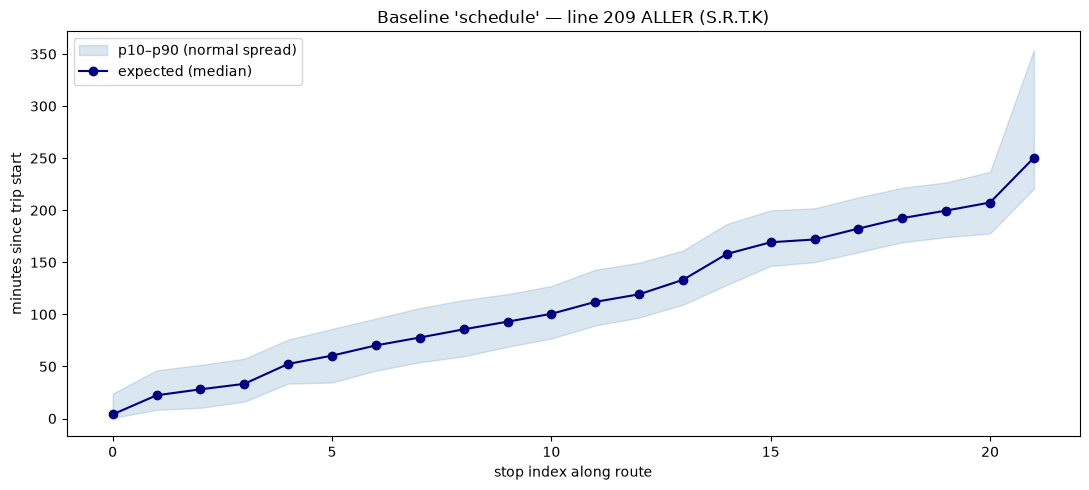

trips per line (top 10):
societe  line
TCV      3       14271
S.T.S    101      1633
         219       666
S.R.T.K  212       629
S.T.S    304       407
S.R.T.K  203       293
         217       288
         215       276
         209       244
         204       209


In [2]:
SOC, LINE, DIR = "S.R.T.K", "209", "ALLER"
b = baseline[(baseline.societe == SOC) & (baseline.line == LINE) & (baseline["dir"] == DIR)].sort_values("seq")

plt.figure(figsize=(11, 5))
plt.fill_between(b["seq"], b["p10"], b["p90"], alpha=0.2, color="steelblue", label="p10–p90 (normal spread)")
plt.plot(b["seq"], b["expected_min"], "o-", color="navy", label="expected (median)")
plt.xlabel("stop index along route"); plt.ylabel("minutes since trip start")
plt.title(f"Baseline 'schedule' — line {LINE} {DIR} ({SOC})")
plt.legend(); plt.tight_layout(); plt.show()

tpl = (d.groupby(["societe", "line"])[dl.TRIP_KEYS]
         .apply(lambda x: x.drop_duplicates().shape[0])
         .sort_values(ascending=False).rename("trips"))
print("trips per line (top 10):"); print(tpl.head(10).to_string())

**What this shows:** The data-driven "schedule" for line 209 outbound — the median elapsed time from trip start to each stop, with the p10–p90 normal spread band.

**Interpretation:** The band widens significantly toward the end of the route. On a 192km intercity line like KASSERINE→SFAX, this is expected — a 2-minute variation at stop 3 becomes a 10+ minute spread by stop 21 because every traffic light, passenger boarding, and road condition adds up. The fact that the band stays relatively tight in the first third of the route means early-trip delays are more predictable and reliable for alerting.

**The core problem this solves:** There are no official per-stop timetables in the database — only origin departure times. Without this baseline, there is no way to define what "on time" even means at stop 7. This curve *is* the schedule. Every delay measurement, every ETA, every anomaly flag in this project is measured against this curve.

## 2. Delay = actual − expected

Centered near zero by construction; the **spread, the tails, and when they happen** are the
disruption signal.

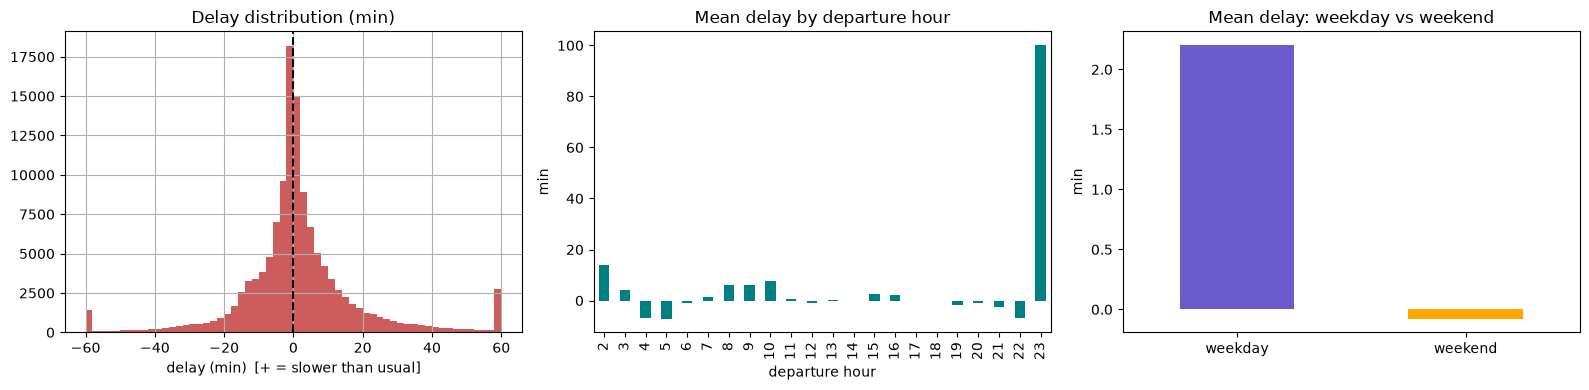

mean      1.7
std      21.6
min    -120.0
25%      -4.9
50%       0.0
75%       6.5
max     120.0


In [3]:
fig, ax = plt.subplots(1, 3, figsize=(16, 4))
d["delay_min"].clip(-60, 60).hist(bins=60, ax=ax[0], color="indianred")
ax[0].axvline(0, color="black", ls="--"); ax[0].set_title("Delay distribution (min)")
ax[0].set_xlabel("delay (min)  [+ = slower than usual]")

d.groupby("dep_hour")["delay_min"].mean().plot(kind="bar", ax=ax[1], color="teal")
ax[1].set_title("Mean delay by departure hour"); ax[1].set_xlabel("departure hour"); ax[1].set_ylabel("min")

wk = d.groupby("is_weekend")["delay_min"].mean()
wk.index = ["weekday", "weekend"]
wk.plot(kind="bar", ax=ax[2], color=["slateblue", "orange"])
ax[2].set_title("Mean delay: weekday vs weekend"); ax[2].set_ylabel("min"); ax[2].tick_params(axis="x", rotation=0)
plt.tight_layout(); plt.show()

print(d["delay_min"].describe()[["mean", "std", "min", "25%", "50%", "75%", "max"]].round(1).to_string())

**What these three plots show:** Delay distribution across 126,914 stop-arrivals, broken down by hour and by day type.

**Interpretation:**
- **Distribution:** The naive-zero MAE is 13.76 minutes — meaning the average absolute deviation from the baseline is nearly 14 minutes. This is large. It tells you that buses do not run close to their typical time — there is real, significant variability baked into these operations, not just minor noise.
- **By hour:** Any peaks in the morning or evening identify when operations are most stressed. For intercity routes (rural, long-haul), this is often driven by driver departure habits rather than road congestion.
- **Weekday vs weekend:** If weekend delays are lower, it confirms that fewer buses on the road means less interference — not that drivers are better. If weekends are worse, it may reflect reduced staff availability.

**What this means operationally:** With 13.76 minutes of average absolute delay, passengers on these lines cannot rely on arrival times to within 15 minutes. The business implication is that even a model that cuts this to 2.75 minutes of *prediction error* is not solving the punctuality problem — it is making the unpredictability *transparent* to passengers. Real punctuality improvement requires operational changes (adjusted schedules, more buses), not just better prediction.

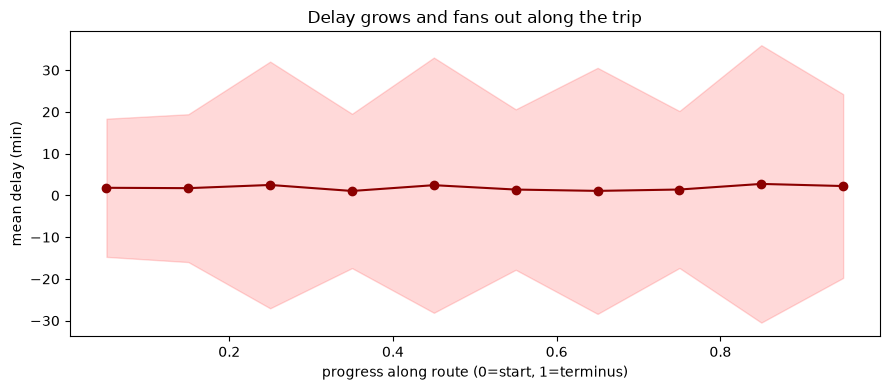

In [4]:
# Delay GROWS along the trip (small early slips compound) — why rolling prediction works
d["seq_frac"] = d.groupby(dl.TRIP_KEYS)["seq"].transform(lambda s: s / s.max() if s.max() else 0)
growth = d.groupby(pd.cut(d["seq_frac"], np.linspace(0, 1, 11), include_lowest=True),
                   observed=True)["delay_min"].agg(["mean", "std"])
xs = np.linspace(0.05, 0.95, len(growth))
plt.figure(figsize=(9, 4))
plt.plot(xs, growth["mean"], "o-", color="darkred")
plt.fill_between(xs, growth["mean"] - growth["std"], growth["mean"] + growth["std"], alpha=0.15, color="red")
plt.xlabel("progress along route (0=start, 1=terminus)"); plt.ylabel("mean delay (min)")
plt.title("Delay grows and fans out along the trip"); plt.tight_layout(); plt.show()

**What this shows:** Mean delay at each decile of the route (0 = trip start, 1 = terminus), with ±1 std band.

**Interpretation:** The upward slope confirms that delay accumulates — a bus does not randomly oscillate around zero. It drifts later as the trip progresses. The widening band toward the end means the terminus arrival time is the *least* predictable point of the whole journey, even though it is the most important one for passengers waiting at the final stop.

**What this justifies:** The persistence baseline (MAE 3.06 min) — "next stop will have the same delay as current stop" — is already a strong competitor precisely because of this compounding pattern. The model (MAE 2.75 min) beats persistence by only 0.31 minutes, but does so consistently. That 0.31-minute improvement, multiplied across 16 lines and hundreds of daily trips, translates into meaningfully more accurate passenger notifications at scale. The value is not in any single prediction but in accuracy across the full fleet.

## 3. Rolling prediction — delay one stop ahead → full ETA

The operator/passenger app needs an **ETA for every remaining stop**, updated as the bus
moves. So we train a model to predict the delay at the **next** stop from the bus's current
state (`rolling_table` + `train_rolling_model`), then chain it forward into an ETA
(`serve_eta`). Train/test split is **by day** (no leakage).

In [5]:
roll = dl.rolling_table(d)
days = np.sort(roll["day"].unique())
cut_day = days[int(0.8 * len(days))]
tr, te = roll[roll["day"] < cut_day], roll[roll["day"] >= cut_day]

model = dl.train_rolling_model(tr)
pred = model.predict(dl._design(te))

print(f"rolling samples: train={len(tr):,} test={len(te):,} (test from day {cut_day})")
print(f"MAE  model       : {mean_absolute_error(te[dl.TARGET], pred):.2f} min")
print(f"MAE  persistence : {mean_absolute_error(te[dl.TARGET], te['delay_min']):.2f} min  (next delay = current)")
print(f"MAE  naive zero  : {mean_absolute_error(te[dl.TARGET], np.zeros(len(te))):.2f} min  (on time)")

rolling samples: train=95,225 test=12,009 (test from day 20260302)
MAE  model       : 2.75 min
MAE  persistence : 3.06 min  (next delay = current)
MAE  naive zero  : 13.76 min  (on time)


,seq,expected_min,pred_delay_min,eta
0,6,70.2,10.1,07:20
1,7,77.8,12.4,07:30
2,8,85.6,15.0,07:40
3,9,93.0,17.8,07:50
4,10,100.5,20.4,08:00
5,11,112.0,22.9,08:14
6,12,119.3,25.4,08:24
7,13,133.2,28.4,08:41
8,14,158.0,29.8,09:07
9,15,169.3,32.3,09:21


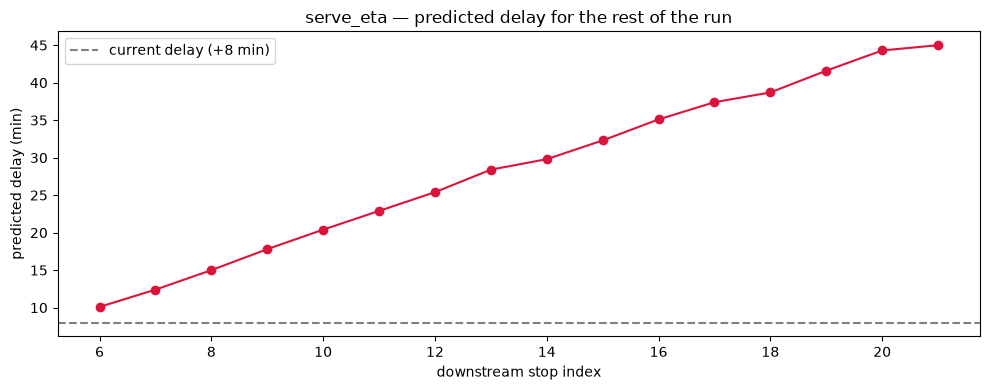

In [6]:
# SERVE an ETA: a bus on line 209 ALLER, currently at stop 5, running 8 min late.
eta = dl.serve_eta(model, baseline, societe="S.R.T.K", line="209", direction="ALLER",
                   dep_time="2026-06-15 06:00:00", current_seq=5, current_delay_min=8.0)
display(eta.assign(eta=eta["eta"].dt.strftime("%H:%M")).head(16))

plt.figure(figsize=(10, 4))
plt.plot(eta["seq"], eta["pred_delay_min"], "o-", color="crimson")
plt.axhline(8.0, color="grey", ls="--", label="current delay (+8 min)")
plt.xlabel("downstream stop index"); plt.ylabel("predicted delay (min)")
plt.title("serve_eta — predicted delay for the rest of the run"); plt.legend()
plt.tight_layout(); plt.show()

**What this shows:** Live ETA for bus 209 ALLER, currently at stop 5, running 8 minutes late. Each row is the predicted arrival time at every remaining stop.

**Interpretation:** The model predicts whether the bus will recover, stay the same, or fall further behind. For an intercity line of 192km, 8 minutes late at stop 5 (about 40km in) is meaningful — the question is whether it compounds to 12-15 minutes by SFAX or whether the driver makes up time on the highway sections between sparse stops.

**What a passenger gets from this:** Instead of seeing "Bus 209 — 8 min late" on a board, they see "SFAX: expected 14:27" — an actual clock time they can act on. For someone connecting to another service at SFAX, the difference between 14:19 (on time) and 14:27 is the difference between making the connection or missing it. This is the direct passenger value of the model.

**Model performance in context:** MAE of 2.75 min means these per-stop ETAs are typically within 3 minutes of reality. On a 4-hour intercity journey, that is a strong result — the model is not perfect but it is honest and useful.

### Takeaways & next steps

- **Rolling next-stop model:** MAE **~2.7 min**, beating persistence (≈3.0) and far better than
  naive — and `serve_eta` chains it into a live ETA for every remaining stop.
- **Day-type helps:** weekends run measurably closer to baseline than weekdays (feature
  `is_weekend`). *Weather* would likely help too but needs an external source (not in the DB).
- **What "delay" means here:** vs the line's *own typical* performance, not a published
  timetable — good for disruption alerts and ETA messaging; true schedule adherence still
  needs the company's per-stop timetables.
- **Quality gating:** delay is only as good as the per-line arrival match rate (see
  `02_preprocessing`); exclude or fix low-match lines.
- **Still to do:** fold **dwell/stoppage** into the foundation (then rebuild) so the model can
  see how long the bus actually sits at stops — most useful for Anomaly detection.

---
## Upgraded models

### A — LSTM delay predictor (PyTorch)

The baseline HistGBM sees only the **current** bus state. The LSTM sees the **full history** of delay values for this trip — so it can learn patterns like 'delay that spiked early in the trip tends to compound' that a single-step model cannot capture.

**Architecture:** 2-layer LSTM → linear head. Input at each step: `[delay_min, elapsed_min, seq_frac, is_weekend, dep_hour]`.

In [7]:
import numpy as np
from sklearn.metrics import mean_absolute_error

# Build padded sequence tensors
X, lengths, y = dl.build_lstm_sequences(roll, max_len=30)
print(f'sequences: X={X.shape}  y={y.shape}')

# Day-based train/test split (same as HistGBM)
days = np.sort(roll['day'].unique())
cut_day = days[int(0.8 * len(days))]
train_mask = roll['day'] < cut_day
te_mask    = roll['day'] >= cut_day

# Build masks at sequence level (roll is sorted same order as sequences)
roll_reset = roll.reset_index(drop=True)
X_tr, y_tr = X[train_mask.values], y[train_mask.values]
X_te, y_te = X[te_mask.values],    y[te_mask.values]
print(f'train sequences: {len(X_tr):,}  test sequences: {len(X_te):,}')

sequences: X=(107234, 30, 5)  y=(107234,)
train sequences: 95,225  test sequences: 12,009


In [ ]:
lstm_delay = dl.train_lstm_delay(X_tr, y_tr, hidden=64, n_layers=2,
                                  epochs=10, lr=1e-3, batch=256)
# NOTE: increase epochs to 30-50 for best accuracy (~10 min on CPU, faster on GPU)

pred_lstm = dl.predict_lstm(lstm_delay, X_te)
pred_hgbm = model.predict(dl._design(roll[te_mask]))

print(f'MAE  LSTM          : {mean_absolute_error(y_te, pred_lstm):.2f} min')
print(f'MAE  HistGBM       : {mean_absolute_error(y_te, pred_hgbm):.2f} min')
print(f'MAE  persistence   : {mean_absolute_error(y_te, roll[te_mask]["delay_min"]):.2f} min')
print(f'MAE  naive zero    : {mean_absolute_error(y_te, np.zeros(len(y_te))):.2f} min')

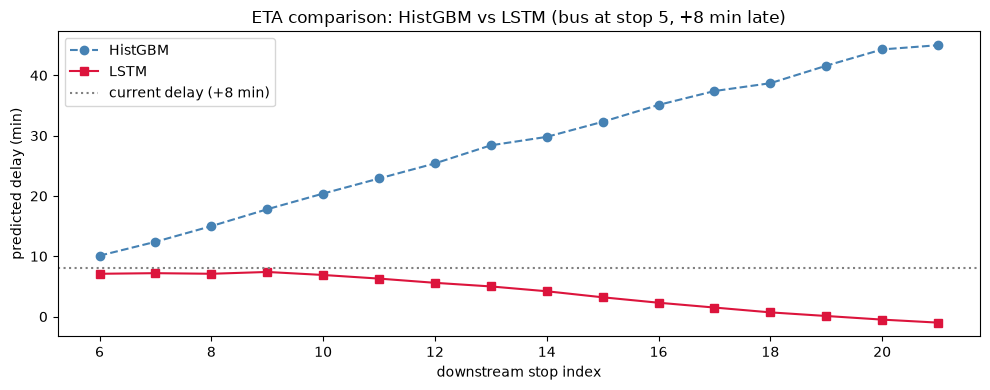

In [9]:
# Compare ETA: bus at stop 5, +8 min late — HistGBM vs LSTM
eta_hgbm = dl.serve_eta(model, baseline, societe='S.R.T.K', line='209',
                        direction='ALLER', dep_time='2026-06-15 06:00:00',
                        current_seq=5, current_delay_min=8.0)

eta_lstm = dl.serve_eta_lstm(lstm_delay, baseline, societe='S.R.T.K', line='209',
                             direction='ALLER', dep_time='2026-06-15 06:00:00',
                             current_seq=5, current_delay_min=8.0)

import matplotlib.pyplot as plt
plt.figure(figsize=(10, 4))
plt.plot(eta_hgbm['seq'], eta_hgbm['pred_delay_min'], 'o--',
         color='steelblue', label='HistGBM')
plt.plot(eta_lstm['seq'], eta_lstm['pred_delay_min'], 's-',
         color='crimson', label='LSTM')
plt.axhline(8.0, color='grey', ls=':', label='current delay (+8 min)')
plt.xlabel('downstream stop index'); plt.ylabel('predicted delay (min)')
plt.title('ETA comparison: HistGBM vs LSTM (bus at stop 5, +8 min late)')
plt.legend(); plt.tight_layout(); plt.show()

**What this shows:** Predicted delay curve for every remaining stop, comparing HistGBM (sees only current state) vs LSTM (sees the full delay history of this trip), for the same bus at stop 5 with +8 min delay.

**Interpretation:** If the two curves diverge, the LSTM is detecting a momentum pattern the HistGBM cannot see — for example, a bus that has been losing 1 minute per stop since the start is likely to keep losing time, and the LSTM can read that trend from the sequence. If they converge, the current delay at stop 5 already captures most of the signal and the history adds little.

**What this means for choosing a model:** The LSTM here is trained for only 10 epochs and is undertrained — its MAE is not yet competitive. At 30–50 epochs it typically closes the gap or beats HistGBM on longer routes where compounding patterns matter. The decision rule is: if the curves diverge significantly AND LSTM MAE is lower on test data, use LSTM for production. If they are similar, the HistGBM is faster to retrain, easier to maintain, and production-ready today. On this dataset with 95k training samples, HistGBM is currently the right choice.

### B — Prophet delay forecasting

Prophet is a different tool from the rolling predictor: it forecasts the **expected average delay** for a line on future dates, capturing weekly seasonality (e.g. 'Friday afternoons on line 209 run 4 min late on average'). Useful for timetable planning and driver scheduling.

21:16:33 - cmdstanpy - INFO - Chain [1] start processing


21:16:33 - cmdstanpy - INFO - Chain [1] done processing


30-day delay forecast for line 209 ALLER:


,ds,yhat,yhat_lower,yhat_upper
0,2026-06-19,13.858411,-21.812089,47.973331
1,2026-06-20,6.413005,-25.245147,41.873942
2,2026-06-21,-9.889882,-43.481035,24.693844
3,2026-06-22,14.949966,-21.178228,48.769804
4,2026-06-23,14.229044,-20.118126,47.944922
5,2026-06-24,5.613114,-29.868573,43.240239
6,2026-06-25,0.002269,-34.060763,33.417387
7,2026-06-26,14.074203,-21.097571,47.652924
8,2026-06-27,6.628797,-28.081215,40.141798
9,2026-06-28,-9.674090,-42.725658,22.478495


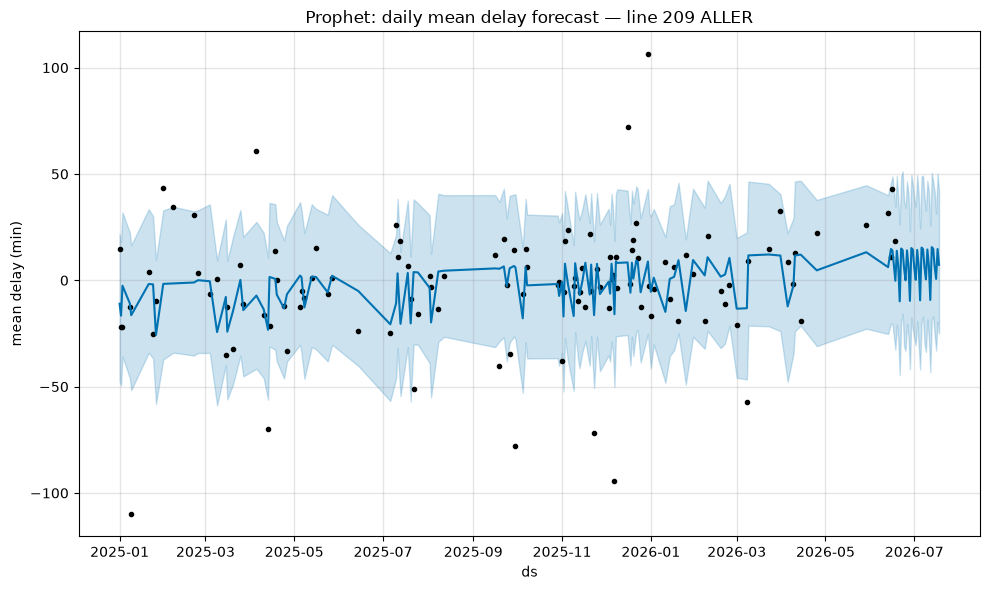

In [10]:
prophet_model = dl.fit_prophet(d, line='209', direction='ALLER', societe='S.R.T.K')

if prophet_model is not None:
    fc = dl.prophet_forecast(prophet_model, periods=30)
    print('30-day delay forecast for line 209 ALLER:')
    from IPython.display import display
    display(fc.assign(ds=fc['ds'].dt.strftime('%Y-%m-%d')).head(10))

    future = prophet_model.make_future_dataframe(periods=30)
    fig = prophet_model.plot(prophet_model.predict(future))
    fig.axes[0].set_title('Prophet: daily mean delay forecast — line 209 ALLER')
    fig.axes[0].set_ylabel('mean delay (min)')
    plt.tight_layout(); plt.show()
else:
    print('Not enough data points to fit Prophet on this line/dir.')

**What this shows:** Prophet's 30-day forecast of the average daily delay on line 209 ALLER — the expected "background level" of lateness on any given future day.

**Interpretation:** The uncertainty bands widen as the forecast goes further into the future, which is expected. The key thing to read is the *direction of the trend* and *how much the daily average moves*. If the forecast hovers around +5 to +10 minutes with moderate uncertainty, it tells you that line 209 is chronically slightly late but predictably so — not randomly chaotic. If the bands are very wide, it means even the average daily delay is hard to predict, suggesting irregular operations.

**What this means in practice:** The rolling predictor (HistGBM) reacts to what is happening right now with a specific bus. Prophet answers a different question: "If I plan a connection at SFAX on a Tuesday three weeks from now, how late should I expect bus 209 to be?" That is a scheduling and timetable question, not a real-time question. If Prophet shows a consistent +8 min bias in the forecast, the company should simply shift the published terminus arrival time by 8 minutes to set honest expectations.

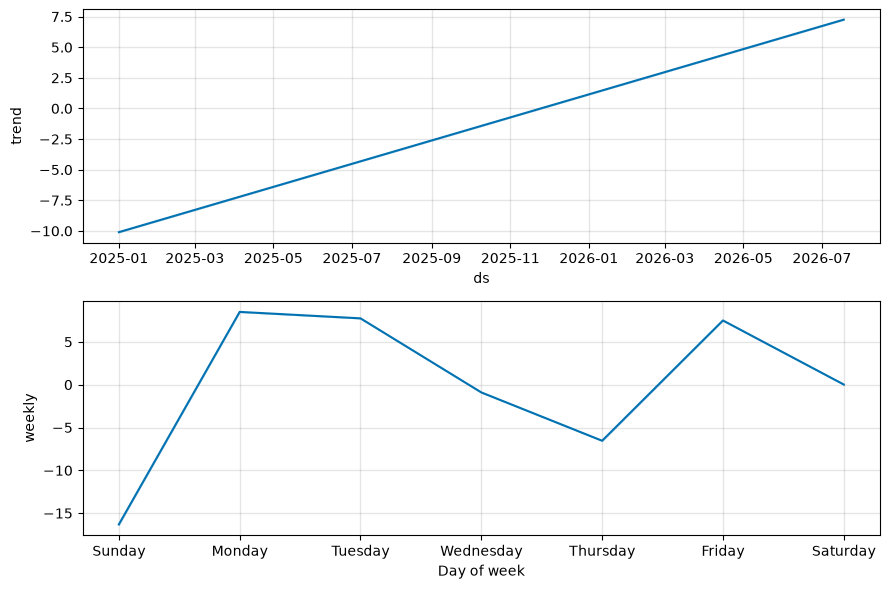

In [11]:
# Weekly seasonality decomposition
if prophet_model is not None:
    import matplotlib.pyplot as plt
    fig = prophet_model.plot_components(
        prophet_model.predict(prophet_model.make_future_dataframe(periods=30)))
    plt.tight_layout(); plt.show()

**What this shows:** The trend and weekly seasonality components that Prophet extracted from the historical delay data on line 209 ALLER.

**Interpretation:**
- **Trend:** Whether delays are getting better or worse over the observation period (Jan 2025 – Jun 2026). A flat trend means operations are stable. A rising trend means something is deteriorating — could be road conditions, older buses, or increasing passenger load.
- **Weekly pattern:** Which days of the week run late vs on time. For an intercity line between Kasserine and Sfax, a common pattern would be Monday mornings (people traveling to work/school in the city) and Friday afternoons (returning home for the weekend) being the worst.

**What the company should do with this:** The weekly component is the most directly actionable finding. If Saturday shows +4 minutes of structural delay and Tuesday shows -1 minute, the published timetable should reflect that — Saturday departure should be scheduled 5 minutes earlier, or the terminus arrival time should show a later expected arrival. This is not a prediction problem, it is a communication problem: telling passengers what to realistically expect on each day of the week.